<a href="https://colab.research.google.com/github/manav1234-creator/spam-mail-detector/blob/main/SMS_Spam_Collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# SPAM MAIL DETECTION USING MACHINE LEARNING
# ============================================

print("Spam Mail Detection Project")
print("Using NLP, TF-IDF and Naive Bayes")

Spam Mail Detection Project
Using NLP, TF-IDF and Naive Bayes


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

zip_path = "sms_spam_collection.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("sms_dataset")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [5]:
import os

for root, dirs, files in os.walk("sms_dataset"):
    for file in files:
        print(os.path.join(root, file))

sms_dataset/readme
sms_dataset/SMSSpamCollection


In [6]:
file_path = "sms_dataset/SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 5572
Number of Columns: 2


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
label      0
message    0
dtype: int64


In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 403


In [12]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(5169, 2)


In [13]:
print(df["label"].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


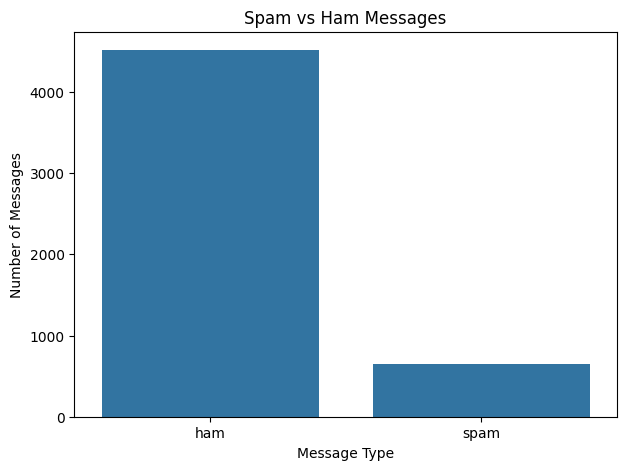

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [15]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [16]:
df["clean_message"] = df["message"].apply(clean_text)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [17]:
comparison = df[["message", "clean_message"]].head(10)

comparison

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


In [18]:
df["label_numeric"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,clean_message,label_numeric
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,1
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,0


In [19]:
print(df["label_numeric"].value_counts())

label_numeric
0    4516
1     653
Name: count, dtype: int64


In [20]:
X = df["clean_message"]

y = df["label_numeric"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (5169,)
Target: (5169,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [22]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 5000)
Testing TF-IDF shape: (1034, 5000)


In [23]:
model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [24]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 97.0 %


In [26]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", round(precision, 4))

Precision: 1.0


In [27]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", round(recall, 4))

Recall: 0.7634


In [28]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", round(f1, 4))

F1 Score: 0.8658


In [29]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       1.00      0.76      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034



In [30]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[903   0]
 [ 31 100]]


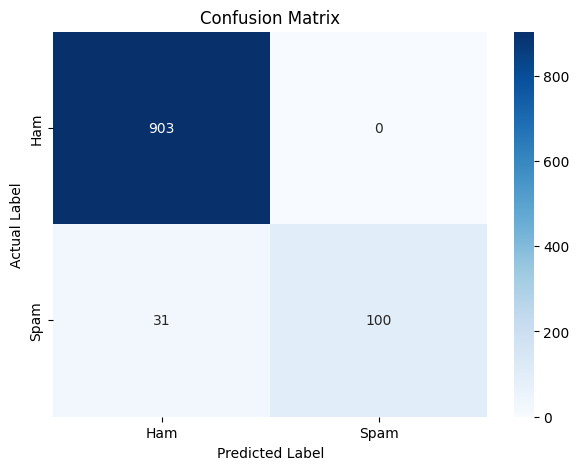

In [31]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

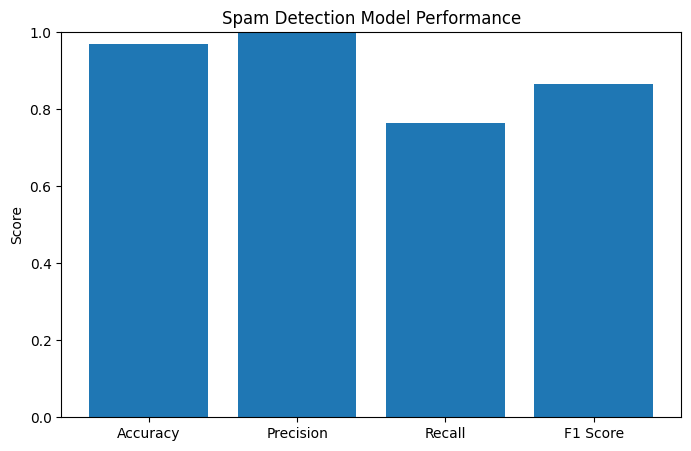

In [32]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(8, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)

plt.title("Spam Detection Model Performance")
plt.ylabel("Score")

plt.show()

In [33]:
def predict_message(message):

    cleaned = clean_text(message)

    transformed = tfidf.transform([cleaned])

    prediction = model.predict(transformed)[0]

    probability = model.predict_proba(transformed)[0]

    if prediction == 1:
        result = "SPAM"
        confidence = probability[1]
    else:
        result = "HAM"
        confidence = probability[0]

    print("Message:", message)
    print("Prediction:", result)
    print("Confidence:", round(confidence * 100, 2), "%")

In [34]:
predict_message(
    "Congratulations! You have won a free prize. Click now to claim your reward!"
)

Message: Congratulations! You have won a free prize. Click now to claim your reward!
Prediction: SPAM
Confidence: 98.39 %


In [35]:
predict_message(
    "Hey, are you coming to college tomorrow?"
)

Message: Hey, are you coming to college tomorrow?
Prediction: HAM
Confidence: 99.32 %


In [ ]:
message = input("Enter your message: ")

predict_message(message)

In [ ]:
from collections import Counter

spam_words = " ".join(
    df[df["label"] == "spam"]["clean_message"]
).split()

word_counts = Counter(spam_words)

common_spam_words = word_counts.most_common(20)

common_spam_words

In [ ]:
words = [word for word, count in common_spam_words]
counts = [count for word, count in common_spam_words]

plt.figure(figsize=(10, 6))

plt.barh(
    words[::-1],
    counts[::-1]
)

plt.title("Most Common Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [ ]:
print("""
====================================================
             PROJECT SUMMARY
====================================================

Project: Spam Mail Detection

Dataset:
SMS Spam Collection

Techniques Used:
1. Text Preprocessing
2. TF-IDF Vectorization
3. Naive Bayes Classification

Evaluation Metrics:
1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. Confusion Matrix

The model learns patterns from text messages and
classifies them as either Spam or Ham.

====================================================
""")

In [ ]:
df.to_csv(
    "processed_spam_dataset.csv",
    index=False
)

print("Processed dataset saved successfully!")

In [ ]:
from google.colab import files

files.download("processed_spam_dataset.csv")